# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

rng = np.random.default_rng(0)

In [2]:
d = 40
k = 8
sigma = 0.1
n = 1500

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [3]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [4]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

S_lr = (sample(W0 + DeltaW_lr).T @ sample(W0 + DeltaW_lr)) / n
S_dense = (sample(W0 + DeltaW_dense).T @ sample(W0 + DeltaW_dense)) / n

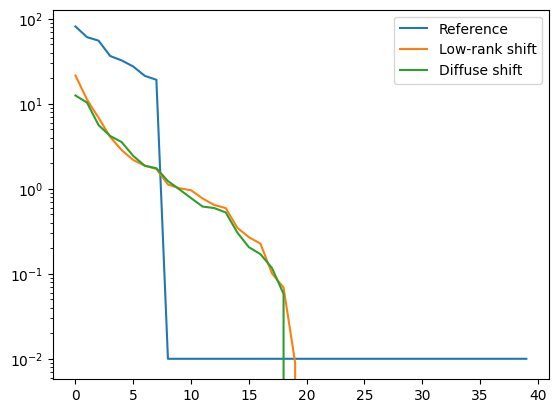

In [5]:
eig0 = eigvalsh(Sigma0)
eig_lr = eigvalsh(S_lr)
eig_dense = eigvalsh(S_dense)

plt.semilogy(eig0[::-1], label='Reference')
plt.semilogy(eig_lr[::-1], label='Low-rank shift')
plt.semilogy(eig_dense[::-1], label='Diffuse shift')
plt.legend()
plt.show()

In [6]:
# Low-Rank
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

# Diffuse
D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

print(f"Frobenius norm of DeltaW_lr: {np.linalg.norm(DeltaW_lr, 'fro'):.4f}")
print(f"Frobenius norm of DeltaW_dense: {np.linalg.norm(DeltaW_dense, 'fro'):.4f}")
print(f"Rank of DeltaW_lr: {np.linalg.matrix_rank(DeltaW_lr)}")
print(f"Rank of DeltaW_dense: {np.linalg.matrix_rank(DeltaW_dense)}")

Frobenius norm of DeltaW_lr: 33.7072
Frobenius norm of DeltaW_dense: 33.7072
Rank of DeltaW_lr: 2
Rank of DeltaW_dense: 8


In [7]:
X_lr = sample(W0 + DeltaW_lr)
X_dense = sample(W0 + DeltaW_dense)

S_lr = (X_lr.T @ X_lr) / n
S_dense = (X_dense.T @ X_dense) / n

In [8]:
eig0 = eigvalsh(Sigma0)
eig_lr = eigvalsh(S_lr)
eig_dense = eigvalsh(S_dense)

eig0 = np.sort(eig0)[::-1]
eig_lr = np.sort(eig_lr)[::-1]
eig_dense = np.sort(eig_dense)[::-1]

print("Top 10 Eigenvalues:")
print(f"{'Index':<8}{'Reference':<15}{'Low-rank':<15}{'Diffuse':<15}")
print("-" * 53)
for i in range(10):
    print(f"{i+1:<8}{eig0[i]:<15.4f}{eig_lr[i]:<15.4f}{eig_dense[i]:<15.4f}")

Top 10 Eigenvalues:
Index   Reference      Low-rank       Diffuse        
-----------------------------------------------------
1       81.2905        1102.8814      359.3360       
2       60.8976        179.7596       271.1007       
3       55.3590        76.6164        239.9665       
4       36.5448        57.5649        219.1710       
5       32.3855        37.9540        192.9192       
6       27.4706        28.3131        138.3217       
7       21.3098        26.3452        104.6386       
8       19.1942        19.1233        75.4279        
9       0.0100         0.0130         0.0127         
10      0.0100         0.0125         0.0125         


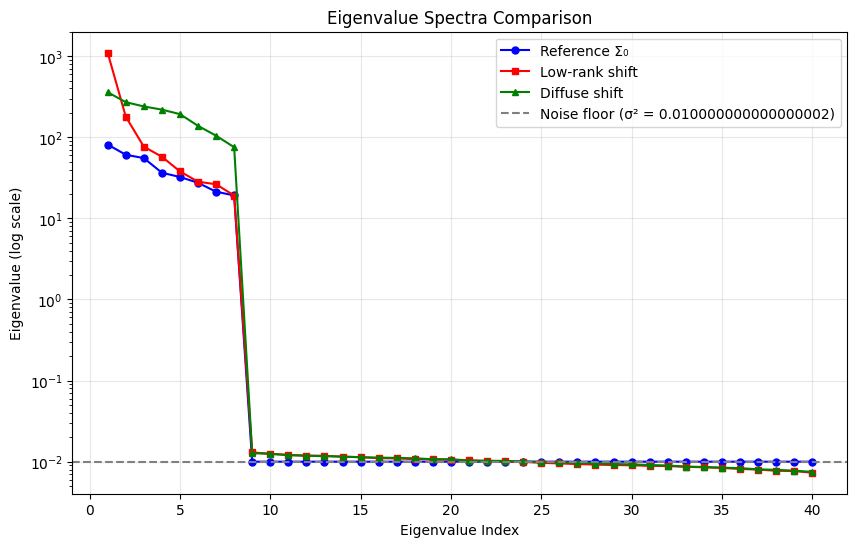

In [9]:
plt.figure(figsize=(10, 6))

indices = np.arange(1, d + 1)

plt.semilogy(indices, eig0, 'b-o', markersize=5, label='Reference Σ₀')
plt.semilogy(indices, eig_lr, 'r-s', markersize=5, label='Low-rank shift')
plt.semilogy(indices, eig_dense, 'g-^', markersize=4, label='Diffuse shift')

plt.axhline(y=sigma**2, color='gray', linestyle='--', label=f'Noise floor (σ² = {sigma**2})')

plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue (log scale)')
plt.title('Eigenvalue Spectra Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
threshold = 0.50  # 50% difference

rel_diff_lr = np.abs(eig_lr - eig0) / eig0
rel_diff_dense = np.abs(eig_dense - eig0) / eig0

n_changes_lr = np.sum(rel_diff_lr > threshold)
n_changes_dense = np.sum(rel_diff_dense > threshold)

print(f"Threshold: {threshold*100:.0f}% relative difference")
print(f"Low-rank:  {n_changes_lr} eigenvalues significantly changed")
print(f"Diffuse:   {n_changes_dense} eigenvalues significantly changed")

Threshold: 50% relative difference
Low-rank:  3 eigenvalues significantly changed
Diffuse:   8 eigenvalues significantly changed


In [16]:
n_changes_lr_signal = np.sum(rel_diff_lr[:k] > threshold)
n_changes_dense_signal = np.sum(rel_diff_dense[:k] > threshold)

print(f"Signal eigenvalues (top {k}):")
print(f"  Low-rank:  {n_changes_lr_signal} out of {k} significantly changed")
print(f"  Diffuse:   {n_changes_dense_signal} out of {k} significantly changed")

print(f"\nRelative differences for signal eigenvalues:")
print(f"{'Index':<8}{'Low-rank %':<15}{'Diffuse %':<15}")
print("-" * 38)
for i in range(k):
    print(f"{i+1:<8}{rel_diff_lr[i]*100:<15.1f}{rel_diff_dense[i]*100:<15.1f}")

Signal eigenvalues (top 8):
  Low-rank:  3 out of 8 significantly changed
  Diffuse:   8 out of 8 significantly changed

Relative differences for signal eigenvalues:
Index   Low-rank %     Diffuse %      
--------------------------------------
1       1256.7         342.0          
2       195.2          345.2          
3       38.4           333.5          
4       57.5           499.7          
5       17.2           495.7          
6       3.1            403.5          
7       23.6           391.0          
8       0.4            293.0          


## Interpretion
### Low-Rank Case
 In the low-rank case, 2-3 eigenvalues change by a large margin (eigenvalue 1 by 1256%, eigenvalue 2 by 195%), the other eigenvalues were close to the reference values
 This is because of the **rank r=2** of the change ΔW = BA. A rank-2 matrix can span 2 independent directions. When we calculate the change to the covariance (Σ_new - Σ₀), this change has at most 2r = 4 rank. Therefore, only 2-4 eigenvalues can be affected by a significant margin.

 ### Diffuse Case
In the diffuse case, all 8 signal eigenvalues are changed(each showing 293-500% change), even though the Frobenius norm is equal to the low-rank case.

This is because the diffuse ΔW has full rank (rank = 8). It can change all k=8 signal directions at the same time. Each eigenvalue receives a moderate share of the change, resulting in moderate changes to many eigenvalues.

### Matrix Rank and Variance Directions

These results show that **matrix rank acts as a constraint** on how many variance directions changes:

1. **Eigenvalues** represent variance along principal directions (eigenvectors)
2. **Rank** limits the number of independent directions a matrix can span
3. A **rank-2 perturbation** can only stretch/compress the covariance ellipsoid along 2-4 axes, leaving the other 36+ axes largely unchanged
4. A **full-rank perturbation** (rank=8) can reshape along all 8 signal axes (but the 32 noise directions remain largely unchanged)

